# TensorFlow/Keras 오차역전파 실습

이 노트북은 TensorFlow/Keras에서 오차역전파를 이해하기 위한 실습 자료입니다.

`tf.GradientTape`를 이용해 직접 기울기를 계산하고, 이후 Keras 모델 학습에서 역전파가 어떻게 자동으로 수행되는지 확인합니다.

In [1]:
# ============================================================
# 1. TensorFlow/Keras 라이브러리 불러오기
# ============================================================

# TensorFlow는 딥러닝 모델 생성, 자동 미분, 학습 기능을 제공하는 라이브러리입니다.
import tensorflow as tf

# Keras는 TensorFlow 안에서 제공되는 고수준 딥러닝 API입니다.
from tensorflow import keras

# layers는 Dense 같은 신경망 계층을 만들 때 사용합니다.
from tensorflow.keras import layers

# NumPy는 배열과 수치 계산을 위해 사용합니다.
import numpy as np

# matplotlib은 손실값 변화를 그래프로 확인하기 위해 사용합니다.
import matplotlib.pyplot as plt

# TensorFlow 버전을 출력합니다.
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ============================================================
# 2. 재현성을 위한 시드 고정
# ============================================================

# TensorFlow의 무작위 연산 결과를 가능한 한 일정하게 만들기 위해 시드를 고정합니다.
tf.random.set_seed(42)

# NumPy의 무작위 연산 결과도 일정하게 만들기 위해 시드를 고정합니다.
np.random.seed(42)

## 1단계: GradientTape로 역전파 이해

TensorFlow에서는 `tf.GradientTape()`가 계산 과정을 기록하고, 그 기록을 바탕으로 기울기를 계산합니다.

In [3]:
# ============================================================
# 3. 단순 계산식 예제
# ============================================================

# 입력값 x를 TensorFlow 상수로 만듭니다.
x = tf.constant(2.0)

# 정답값 target을 TensorFlow 상수로 만듭니다.
target = tf.constant(10.0)

# 가중치 w를 TensorFlow 변수로 만듭니다.
# tf.Variable은 학습 중 값이 변경될 수 있는 텐서입니다.
w = tf.Variable(3.0)

# GradientTape는 이 블록 안의 계산 과정을 기록합니다.
with tf.GradientTape() as tape:
    # 순전파: 입력값과 가중치를 곱해 예측값을 계산합니다.
    prediction = x * w

    # 손실 계산: 정답값과 예측값의 차이를 제곱합니다.
    loss = (target - prediction) ** 2

# loss를 w로 미분하여 기울기를 계산합니다.
gradient = tape.gradient(loss, w)

# 계산 결과를 출력합니다.
print("입력값 x:", x.numpy())
print("초기 가중치 w:", w.numpy())
print("예측값:", prediction.numpy())
print("정답값:", target.numpy())
print("손실값:", loss.numpy())
print("w에 대한 기울기:", gradient.numpy())

입력값 x: 2.0
초기 가중치 w: 3.0
예측값: 6.0
정답값: 10.0
손실값: 16.0
w에 대한 기울기: -16.0


In [4]:
# ============================================================
# 4. 기울기를 사용해 가중치 직접 수정
# ============================================================

# 학습률을 설정합니다.
learning_rate = 0.01

# assign_sub는 변수에서 특정 값을 빼서 업데이트합니다.
# 경사하강법 공식 w = w - learning_rate * gradient를 적용합니다.
w.assign_sub(learning_rate * gradient)

# 수정된 가중치를 출력합니다.
print("수정 후 가중치 w:", w.numpy())

수정 후 가중치 w: 3.16


## 2단계: 반복 학습으로 손실 줄이기

In [5]:
# ============================================================
# 5. 단일 가중치 반복 학습
# ============================================================

# 학습할 가중치를 다시 초기화합니다.
w = tf.Variable(3.0)

# 입력값과 정답값을 설정합니다.
x = tf.constant(2.0)
target = tf.constant(10.0)

# 학습률을 설정합니다.
learning_rate = 0.05

# 손실값 기록 리스트를 생성합니다.
loss_history = []

# 30번 반복 학습합니다.
for epoch in range(30):
    # GradientTape로 순전파 계산 과정을 기록합니다.
    with tf.GradientTape() as tape:
        # 순전파: 현재 가중치로 예측값을 계산합니다.
        prediction = x * w

        # 손실 계산: 예측값과 정답값의 차이를 제곱합니다.
        loss = (target - prediction) ** 2

    # 손실을 w에 대해 미분하여 기울기를 계산합니다.
    gradient = tape.gradient(loss, w)

    # 경사하강법으로 가중치를 업데이트합니다.
    w.assign_sub(learning_rate * gradient)

    # 손실값을 기록합니다.
    loss_history.append(loss.numpy())

    # 학습 상태를 출력합니다.
    print(f"epoch={epoch+1:02d}, w={w.numpy():.4f}, prediction={prediction.numpy():.4f}, loss={loss.numpy():.4f}")

epoch=01, w=3.8000, prediction=6.0000, loss=16.0000
epoch=02, w=4.2800, prediction=7.6000, loss=5.7600
epoch=03, w=4.5680, prediction=8.5600, loss=2.0736
epoch=04, w=4.7408, prediction=9.1360, loss=0.7465
epoch=05, w=4.8445, prediction=9.4816, loss=0.2687
epoch=06, w=4.9067, prediction=9.6890, loss=0.0967
epoch=07, w=4.9440, prediction=9.8134, loss=0.0348
epoch=08, w=4.9664, prediction=9.8880, loss=0.0125
epoch=09, w=4.9798, prediction=9.9328, loss=0.0045
epoch=10, w=4.9879, prediction=9.9597, loss=0.0016
epoch=11, w=4.9927, prediction=9.9758, loss=0.0006
epoch=12, w=4.9956, prediction=9.9855, loss=0.0002
epoch=13, w=4.9974, prediction=9.9913, loss=0.0001
epoch=14, w=4.9984, prediction=9.9948, loss=0.0000
epoch=15, w=4.9991, prediction=9.9969, loss=0.0000
epoch=16, w=4.9994, prediction=9.9981, loss=0.0000
epoch=17, w=4.9997, prediction=9.9989, loss=0.0000
epoch=18, w=4.9998, prediction=9.9993, loss=0.0000
epoch=19, w=4.9999, prediction=9.9996, loss=0.0000
epoch=20, w=4.9999, prediction

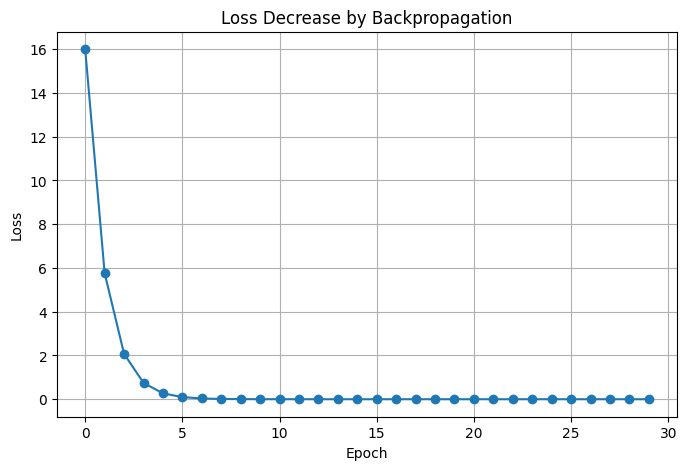

In [6]:
# ============================================================
# 6. 손실 감소 그래프
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker="o")
plt.title("Loss Decrease by Backpropagation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 3단계: Keras 선형 회귀 모델

목표는 `y = 2x + 1` 관계를 학습하는 것입니다.

In [7]:
# ============================================================
# 7. 학습 데이터 생성
# ============================================================

# 입력 데이터입니다. shape은 (샘플 수, 입력 특성 수)입니다.
X = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]], dtype=np.float32)

# 정답 데이터입니다. y = 2x + 1 규칙을 따릅니다.
y = np.array([[3.0], [5.0], [7.0], [9.0], [11.0]], dtype=np.float32)

# 데이터 형태를 출력합니다.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5, 1)
y shape: (5, 1)


In [8]:
# ============================================================
# 8. Keras 선형 회귀 모델 정의
# ============================================================

# Sequential은 계층을 순서대로 쌓는 가장 간단한 모델 작성 방식입니다.
linear_model = keras.Sequential([
    # Dense는 완전연결 계층입니다. 입력 1개를 받아 출력 1개를 만듭니다.
    layers.Dense(units=1, input_shape=(1,))
])

# 모델 구조를 출력합니다.
linear_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ============================================================
# 9. 모델 컴파일
# ============================================================

# compile은 학습에 필요한 최적화 알고리즘과 손실함수를 설정합니다.
linear_model.compile(
    # SGD는 기울기를 사용해 가중치를 수정하는 최적화 알고리즘입니다.
    optimizer=keras.optimizers.SGD(learning_rate=0.01),

    # mse는 평균제곱오차이며 회귀 문제에서 자주 사용합니다.
    loss="mse"
)

In [10]:
# ============================================================
# 10. Keras 모델 학습
# ============================================================

# fit은 내부적으로 순전파, 손실 계산, 역전파, 가중치 업데이트를 반복합니다.
history = linear_model.fit(X, y, epochs=300, verbose=0)

# 학습 완료 메시지를 출력합니다.
print("학습 완료")

학습 완료


In [11]:
# ============================================================
# 11. 학습 결과 확인
# ============================================================

# Dense 계층의 가중치와 편향을 가져옵니다.
weights, bias = linear_model.layers[0].get_weights()

# 정답이 y = 2x + 1이므로 weight는 2, bias는 1에 가까워지는 것이 목표입니다.
print("학습된 weight:", weights[0][0])
print("학습된 bias:", bias[0])

# 새로운 입력값으로 예측합니다.
new_x = np.array([[10.0]], dtype=np.float32)
new_prediction = linear_model.predict(new_x, verbose=0)

# 예측 결과를 출력합니다.
print("x=10일 때 예측값:", new_prediction[0][0])

학습된 weight: 2.000571
학습된 bias: 0.99793965
x=10일 때 예측값: 21.00365


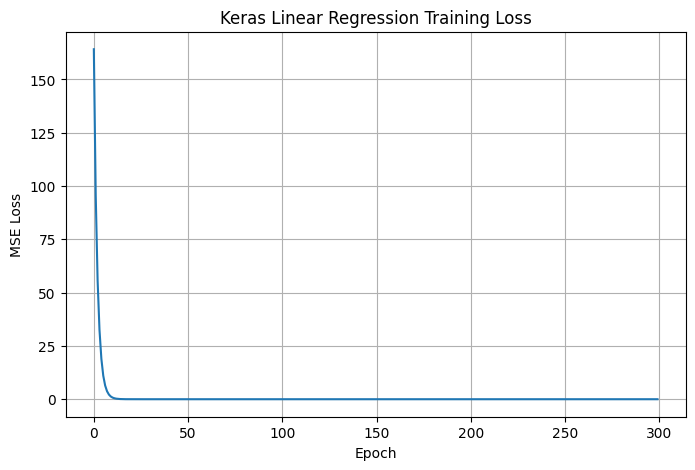

In [12]:
# ============================================================
# 12. 학습 손실 그래프
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"])
plt.title("Keras Linear Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

## 4단계: GradientTape로 Keras 모델 수동 학습

`model.fit()` 내부에서 일어나는 역전파 과정을 직접 작성합니다.

In [13]:
# ============================================================
# 13. 수동 학습용 모델과 손실함수 설정
# ============================================================

# 새 선형 회귀 모델을 생성합니다.
manual_model = keras.Sequential([
    # 입력 1개를 받아 출력 1개를 만드는 Dense 계층입니다.
    layers.Dense(units=1, input_shape=(1,))
])

# 평균제곱오차 손실함수 객체를 생성합니다.
mse_loss = keras.losses.MeanSquaredError()

# SGD 최적화 알고리즘 객체를 생성합니다.
optimizer = keras.optimizers.SGD(learning_rate=0.01)

# NumPy 배열을 TensorFlow 텐서로 변환합니다.
X_tensor = tf.constant(X)
y_tensor = tf.constant(y)

# 손실값 기록 리스트입니다.
manual_losses = []

In [14]:
# ============================================================
# 14. GradientTape 수동 학습 루프
# ============================================================

# 300번 반복 학습합니다.
for epoch in range(300):
    # GradientTape는 모델의 순전파 계산 과정을 기록합니다.
    with tf.GradientTape() as tape:
        # 순전파: 현재 모델로 예측값을 계산합니다.
        predictions = manual_model(X_tensor, training=True)

        # 손실 계산: 예측값과 정답값의 차이를 계산합니다.
        loss = mse_loss(y_tensor, predictions)

    # 모델의 학습 가능한 변수들에 대한 기울기를 계산합니다.
    gradients = tape.gradient(loss, manual_model.trainable_variables)

    # 계산된 기울기를 이용하여 가중치와 편향을 수정합니다.
    optimizer.apply_gradients(zip(gradients, manual_model.trainable_variables))

    # 손실값을 기록합니다.
    manual_losses.append(loss.numpy())

    # 50번마다 손실을 출력합니다.
    if (epoch + 1) % 50 == 0:
        print(f"epoch={epoch+1:03d}, loss={loss.numpy():.6f}")

epoch=050, loss=0.061554
epoch=100, loss=0.043871
epoch=150, loss=0.031267
epoch=200, loss=0.022285
epoch=250, loss=0.015883
epoch=300, loss=0.011320


수동 학습 weight: 2.0688415
수동 학습 bias: 0.7514606


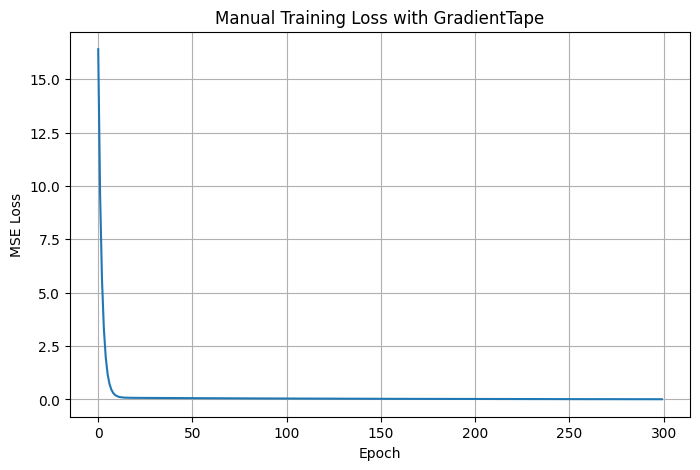

In [15]:
# ============================================================
# 15. 수동 학습 결과 확인
# ============================================================

# 수동 학습 모델의 가중치와 편향을 가져옵니다.
manual_weights, manual_bias = manual_model.layers[0].get_weights()

# 결과를 출력합니다.
print("수동 학습 weight:", manual_weights[0][0])
print("수동 학습 bias:", manual_bias[0])

# 손실 그래프를 출력합니다.
plt.figure(figsize=(8, 5))
plt.plot(manual_losses)
plt.title("Manual Training Loss with GradientTape")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

## 5단계: XOR 다층 신경망

은닉층과 활성화 함수를 사용하면 비선형 문제도 학습할 수 있습니다.

In [16]:
# ============================================================
# 16. XOR 데이터 준비
# ============================================================

# XOR 입력 데이터입니다.
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=np.float32)

# XOR 정답 데이터입니다. 두 입력이 다르면 1, 같으면 0입니다.
y_xor = np.array([[0.0], [1.0], [1.0], [0.0]], dtype=np.float32)

In [17]:
# ============================================================
# 17. XOR 모델 정의
# ============================================================

# 다층 퍼셉트론 모델을 생성합니다.
xor_model = keras.Sequential([
    # 입력 2개를 은닉 뉴런 8개로 변환하고 ReLU 활성화 함수를 적용합니다.
    layers.Dense(units=8, activation="relu", input_shape=(2,)),

    # 두 번째 은닉층입니다. 복잡한 비선형 패턴 학습에 도움을 줍니다.
    layers.Dense(units=8, activation="relu"),

    # 출력층입니다. sigmoid로 0~1 사이 확률 형태를 출력합니다.
    layers.Dense(units=1, activation="sigmoid")
])

# 모델 구조를 출력합니다.
xor_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ============================================================
# 18. XOR 모델 컴파일
# ============================================================

# 이진 분류 문제이므로 binary_crossentropy 손실함수를 사용합니다.
xor_model.compile(
    # Adam은 학습률을 자동 조정하는 최적화 알고리즘입니다.
    optimizer=keras.optimizers.Adam(learning_rate=0.05),

    # 이진 분류 손실함수입니다.
    loss="binary_crossentropy",

    # 정확도를 함께 확인합니다.
    metrics=["accuracy"]
)

In [19]:
# ============================================================
# 19. XOR 모델 학습
# ============================================================

# XOR 데이터는 매우 작으므로 전체 데이터를 반복해서 학습합니다.
xor_history = xor_model.fit(X_xor, y_xor, epochs=1000, verbose=0)

# 학습 완료 메시지를 출력합니다.
print("XOR 모델 학습 완료")

XOR 모델 학습 완료


In [20]:
# ============================================================
# 20. XOR 예측 결과 확인
# ============================================================

# 학습된 모델로 XOR 입력값에 대한 예측 확률을 계산합니다.
xor_probs = xor_model.predict(X_xor, verbose=0)

# 확률이 0.5 이상이면 1, 미만이면 0으로 분류합니다.
xor_classes = (xor_probs >= 0.5).astype(np.float32)

# 결과를 출력합니다.
print("예측 확률:")
print(xor_probs)
print("예측 클래스:")
print(xor_classes)
print("실제 정답:")
print(y_xor)

예측 확률:
[[1.1578100e-03]
 [9.9999106e-01]
 [9.9999064e-01]
 [6.7762976e-06]]
예측 클래스:
[[0.]
 [1.]
 [1.]
 [0.]]
실제 정답:
[[0.]
 [1.]
 [1.]
 [0.]]


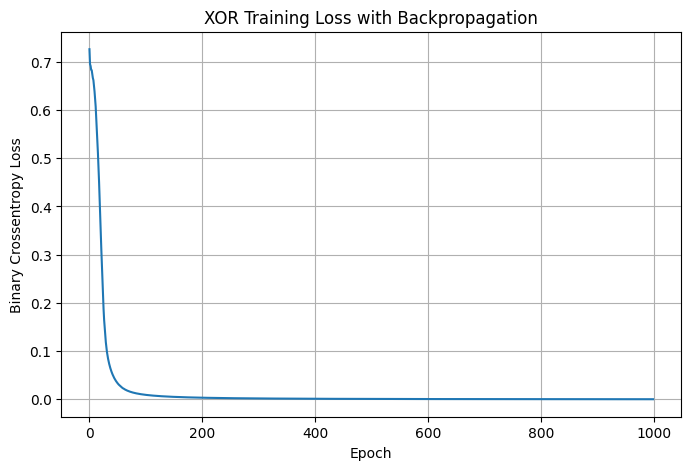

In [21]:
# ============================================================
# 21. XOR 손실 그래프
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(xor_history.history["loss"])
plt.title("XOR Training Loss with Backpropagation")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.grid(True)
plt.show()

# TensorFlow/Keras 핵심 정리

TensorFlow/Keras에서 오차역전파는 두 방식으로 볼 수 있습니다.

`model.fit()`은 내부적으로 순전파, 손실 계산, 역전파, 가중치 업데이트를 자동 수행합니다.

직접 작성할 때는 다음 구조를 사용합니다.

```python
with tf.GradientTape() as tape:
    predictions = model(X)
    loss = loss_fn(y, predictions)

gradients = tape.gradient(loss, model.trainable_variables)
optimizer.apply_gradients(zip(gradients, model.trainable_variables))
```

- `GradientTape` : 계산 과정을 기록합니다.
- `tape.gradient()` : 손실을 기준으로 기울기를 계산합니다.
- `optimizer.apply_gradients()` : 기울기로 가중치를 수정합니다.